# 디버깅 코드
그래프에서 데이터가 어디에 찍히는지

📂 'normal_msg_cold.csv' 분석 중...
평균 비트 길이: 943208.22 ns


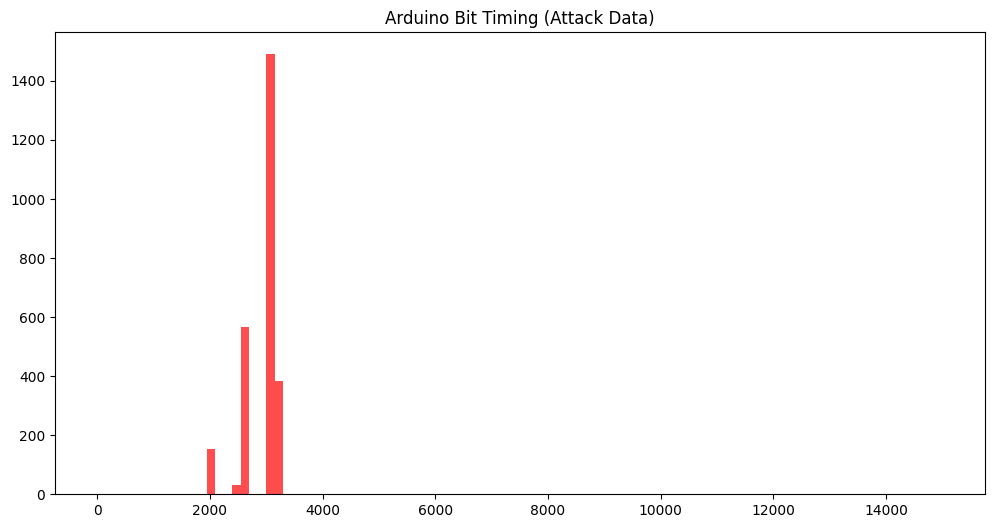

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = 'normal_msg_cold.csv'  # 아두이노 데이터 파일명
print(f"📂 '{filename}' 분석 중...")

df = pd.read_csv(filename)
df.columns = df.columns.str.strip()

timestamps = df.iloc[:, 0].values
signals = df.iloc[:, 1].values
edges = np.where(np.diff(signals) != 0)[0]
durations = timestamps[edges[1:]] - timestamps[edges[:-1]]

print(f"평균 비트 길이: {np.mean(durations):.2f} ns")

plt.figure(figsize=(12, 6))
# 아두이노는 느리니까 범위를 15,000ns까지 넓게 봅니다
plt.hist(durations, bins=100, range=(0, 15000), color='red', alpha=0.7)
plt.title("Arduino Bit Timing (Attack Data)")
plt.show()

# 기기데이터 테스트

🧠 모델 'ids_model_b.pkl' 불러오는 중...
📂 'nano_attack.csv' 로딩 중...
   - 추출된 유효 비트 수: 98개

📊 [IDS 판독 결과]
총 테스트 샘플: 78개
이상 징후(공격) 탐지: 78개
공격 의심 확률: 100.00%

🚨 경고: 이 데이터는 [다른 ECU / 공격]으로 판단됩니다!


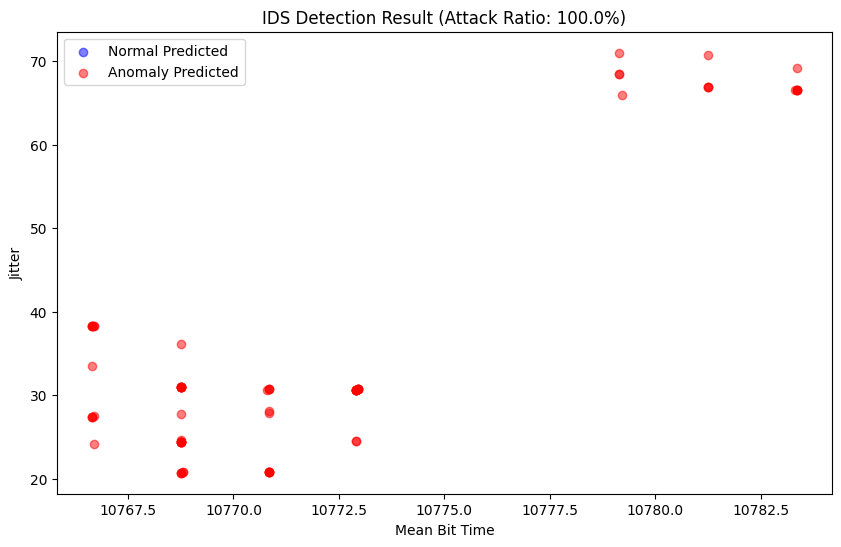

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 설정 (학습 때와 똑같이 맞춰야 함!)
# ---------------------------------------------------------
TEST_FILENAME = 'nano_attack.csv'  # <-- 여기에 테스트할 파일명 입력 (예: normal_hot.csv, attack.csv 등)
MODEL_FILE = 'ids_model_b.pkl'   # 저장된 모델 파일

# 학습 때 썼던 설정 그대로!
MIN_BIT_TIME = 1500
MAX_BIT_TIME = 15000
WINDOW_SIZE = 20

# ---------------------------------------------------------
# 2. 특징 추출 함수 (학습 때와 동일)
# ---------------------------------------------------------
def get_features_from_csv(filename):
    print(f"📂 '{filename}' 로딩 중...")
    try:
        df = pd.read_csv(filename)
        df.columns = df.columns.str.strip()

        timestamps = df.iloc[:, 0].values
        signals = df.iloc[:, 1].values
        edges = np.where(np.diff(signals) != 0)[0]
        durations = timestamps[edges[1:]] - timestamps[edges[:-1]]

        # 필터링
        valid_bits = durations[(durations > MIN_BIT_TIME) & (durations < MAX_BIT_TIME)]
        print(f"   - 추출된 유효 비트 수: {len(valid_bits)}개")

        if len(valid_bits) < WINDOW_SIZE:
            return None

        # 특징 추출
        features = []
        for i in range(0, len(valid_bits) - WINDOW_SIZE, 1):
            window = valid_bits[i : i + WINDOW_SIZE]
            features.append([np.mean(window), np.std(window)])

        return np.array(features)

    except Exception as e:
        print(f"에러 발생: {e}")
        return None

# ---------------------------------------------------------
# 3. 모델 불러오기 & 판별 (핵심!)
# ---------------------------------------------------------
# (1) 모델 로드
print(f"🧠 모델 '{MODEL_FILE}' 불러오는 중...")
loaded_model = joblib.load(MODEL_FILE)

# (2) 새 데이터 특징 추출
X_test = get_features_from_csv(TEST_FILENAME)

if X_test is not None:
    # (3) 판별 시작 (Predict)
    # 결과가 1이면 정상, -1이면 공격
    predictions = loaded_model.predict(X_test)

    # (4) 결과 분석
    total_samples = len(predictions)
    anomalies = list(predictions).count(-1) # 공격으로 판단한 개수
    attack_ratio = (anomalies / total_samples) * 100

    print("\n" + "="*30)
    print(f"📊 [IDS 판독 결과]")
    print(f"총 테스트 샘플: {total_samples}개")
    print(f"이상 징후(공격) 탐지: {anomalies}개")
    print(f"공격 의심 확률: {attack_ratio:.2f}%")
    print("="*30 + "\n")

    # (5) 최종 결론 내리기
    if attack_ratio > 30: # 절반 이상이 이상하면 공격으로 간주
        print("🚨 경고: 이 데이터는 [다른 ECU / 공격]으로 판단됩니다!")
    else:
        print("✅ 확인: 이 데이터는 [정상 ECU]로 판단됩니다.")

    # (6) 시각화 (모델이 본 세상)
    plt.figure(figsize=(10, 6))
    # 정상으로 판별된 것(파랑), 공격으로 판별된 것(빨강)
    plt.scatter(X_test[predictions==1, 0], X_test[predictions==1, 1], c='blue', alpha=0.5, label='Normal Predicted')
    plt.scatter(X_test[predictions==-1, 0], X_test[predictions==-1, 1], c='red', alpha=0.5, label='Anomaly Predicted')
    plt.title(f'IDS Detection Result (Attack Ratio: {attack_ratio:.1f}%)')
    plt.xlabel('Mean Bit Time')
    plt.ylabel('Jitter')
    plt.legend()
    plt.show()

else:
    print("데이터를 처리할 수 없어 판별을 중단합니다.")

# 합성 데이터 테스트
합성 데이터 형식이 달라 올바르게 특징만 추출해 비교하기 위함

🧠 모델 'ids_model_b3.pkl' 로딩 중...
✅ 모델 로드 성공!
📂 합성 데이터 'synthetic_attack.csv' 로딩 및 전처리 중...
   - 원본 데이터 개수 (Bits): 512,000개
   - 원본 데이터 샘플 (µs 예상): [2.00817409 1.99537621 1.97282852 1.99301314 2.01191356]
   - 변환된 데이터 샘플 (ns): [2008.17408726 1995.37620639 1972.82852148 1993.01314251 2011.91356382]
⚙️ 특징(지문) 추출 중...
   ▶ 필터링 후 유효 비트 수: 512,000개

📊 [IDS 판독 결과]
   - 총 테스트 샘플 수: 51198개
   - 공격(이상 징후) 탐지: 51198개
   - 공격 의심 확률: 100.00%
🚨 [결과] 이 데이터는 '공격(다른 하드웨어/가짜)'입니다!


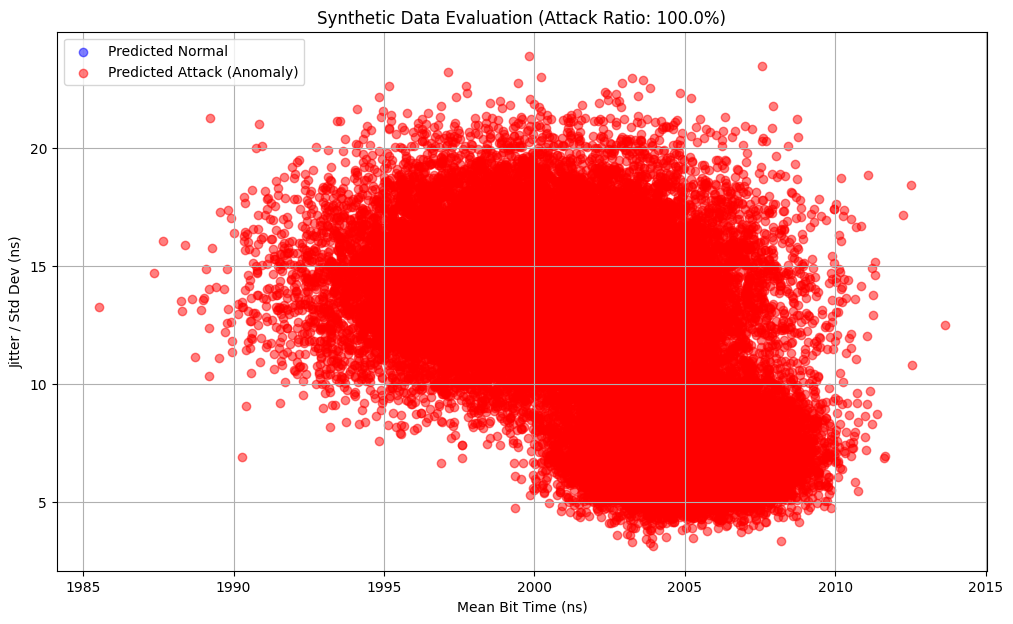

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# ==========================================
# 1. 설정 (학습 때와 동일하게 유지)
# ==========================================
MODEL_FILE = 'ids_model_b3.pkl'       # 저장된 모델 파일명
SYNTHETIC_FILE = 'synthetic_attack.csv' # 합성 데이터 파일명 (업로드한 파일명과 일치시켜 주세요)

# 학습 때 사용한 필터링 및 윈도우 설정
MIN_BIT_TIME = 1500  # 1.5 us
MAX_BIT_TIME = 4000  # 4.0 us
WINDOW_SIZE = 20     # 20개씩 묶어서 특징 추출

# ==========================================
# 2. 특징 추출 함수 (재사용)
# ==========================================
def create_features(durations):
    # 1. 유효 범위 필터링
    valid_bits = durations[(durations > MIN_BIT_TIME) & (durations < MAX_BIT_TIME)]
    print(f"   ▶ 필터링 후 유효 비트 수: {len(valid_bits):,}개")

    if len(valid_bits) < WINDOW_SIZE:
        return np.array([])

    # 2. 특징 추출 (Sliding Window)
    features = []
    # 데이터가 많으므로 step=10 정도로 띄엄띄엄 추출 (속도 향상)
    for i in range(0, len(valid_bits) - WINDOW_SIZE, 10):
        window = valid_bits[i : i + WINDOW_SIZE]
        mean_val = np.mean(window)
        std_val = np.std(window)
        features.append([mean_val, std_val])

    return np.array(features)

# ==========================================
# 3. 실행 및 판별
# ==========================================

# (1) 모델 불러오기
print(f"🧠 모델 '{MODEL_FILE}' 로딩 중...")
try:
    model = joblib.load(MODEL_FILE)
    print("✅ 모델 로드 성공!")
except:
    print("❌ 모델 파일이 없습니다. ids_model_b.pkl 파일이 있는지 확인하세요.")
    exit()

# (2) 합성 데이터 불러오기 & 전처리
print(f"📂 합성 데이터 '{SYNTHETIC_FILE}' 로딩 및 전처리 중...")
try:
    # CSV 읽기
    syn_df = pd.read_csv(SYNTHETIC_FILE)

    # 데이터 구조 확인: 0~127번 열이 비트 데이터라고 가정
    # (Label, ECU_ID 같은 문자열 열은 제외하고 숫자 데이터만 가져옴)
    # iloc[:, 0:128] -> 0번째부터 127번째 열까지 선택
    bit_data = syn_df.iloc[:, 0:128].values.flatten()

    print(f"   - 원본 데이터 개수 (Bits): {len(bit_data):,}개")
    print(f"   - 원본 데이터 샘플 (µs 예상): {bit_data[:5]}")

    # ★ 중요: 단위 변환 (Microseconds -> Nanoseconds) ★
    # 합성 데이터는 1.99, 2.00 (us) 단위이고, 모델은 3000 (ns) 단위로 학습했습니다.
    # 따라서 1000을 곱해줘야 합니다.
    bit_data_ns = bit_data * 1000
    print(f"   - 변환된 데이터 샘플 (ns): {bit_data_ns[:5]}")

    # (3) 특징 추출
    print("⚙️ 특징(지문) 추출 중...")
    X_test = create_features(bit_data_ns)

    if len(X_test) > 0:
        # (4) 모델 예측 (1: 정상, -1: 공격)
        predictions = model.predict(X_test)

        # (5) 결과 분석
        total = len(predictions)
        anomalies = list(predictions).count(-1) # 공격으로 판별된 수
        attack_ratio = (anomalies / total) * 100

        print("\n" + "="*40)
        print(f"📊 [IDS 판독 결과]")
        print(f"   - 총 테스트 샘플 수: {total}개")
        print(f"   - 공격(이상 징후) 탐지: {anomalies}개")
        print(f"   - 공격 의심 확률: {attack_ratio:.2f}%")
        print("="*40)

        if attack_ratio > 50:
            print("🚨 [결과] 이 데이터는 '공격(다른 하드웨어/가짜)'입니다!")
        else:
            print("✅ [결과] 이 데이터는 '정상(등록된 ESP32)'입니다.")

        # (6) 시각화 (산점도)
        plt.figure(figsize=(12, 7))

        # 정상으로 예측한 점 (파란색)
        plt.scatter(X_test[predictions==1, 0], X_test[predictions==1, 1],
                    c='blue', alpha=0.5, label='Predicted Normal')

        # 공격으로 예측한 점 (빨간색)
        plt.scatter(X_test[predictions==-1, 0], X_test[predictions==-1, 1],
                    c='red', alpha=0.5, label='Predicted Attack (Anomaly)')

        plt.title(f'Synthetic Data Evaluation (Attack Ratio: {attack_ratio:.1f}%)')
        plt.xlabel('Mean Bit Time (ns)')
        plt.ylabel('Jitter / Std Dev (ns)')
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("❌ 유효한 특징을 추출하지 못했습니다. (데이터 범위 확인 필요)")

except Exception as e:
    print(f"❌ 오류 발생: {e}")
    print("CSV 파일 형식이 맞는지, 파일명이 정확한지 확인해주세요.")

# 직접 탐지하기
모델 파일 첨부해서 돌리는 게 아니라 한 코드에서 다 돌리기

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[STEP 1] 데이터 통합 및 강건한 모델 학습 (Robust Training)
📂 [Loading] 상온(Room) 데이터 로드: normal_msg.csv ...
📂 [Loading] 고온(Hot) 데이터 로드: normal_msg_hot.csv ...
📂 [Loading] 저온(Cold) 데이터 로드: normal_msg_cold.csv ...
   ▶ 통합된 학습 데이터 크기: 744 샘플 (상온+고온+저온)
   ⚙️ Isolation Forest 모델 학습 중...
   ✅ 학습 완료 (Training Completed)

[STEP 2] 공격 탐지 성능 검증 (Evaluation)
📂 [Loading] ATTACK 데이터 로드: another_esp32.csv ...

📊 [Evaluation Report] Robust IDS Performance
1. 물리적 신호 특성 분석 (Physical Characteristics)
   - Learned Normal Range (Mean)   : 2878 ns ~ 3014 ns
     (Covers Room, Hot, and Cold conditions)
   ------------------------------------------------------------
   - Test Input Mean Bit Time      : 2948 ns
   - Test Input Jitter (Average)   : 304.82 ns

2. IDS 판별 결과 (Classification Result)
   - Total Samples Analyzed        : 96
   - Anomalous Samples Detected    : 23
   - Anomaly Ratio (공

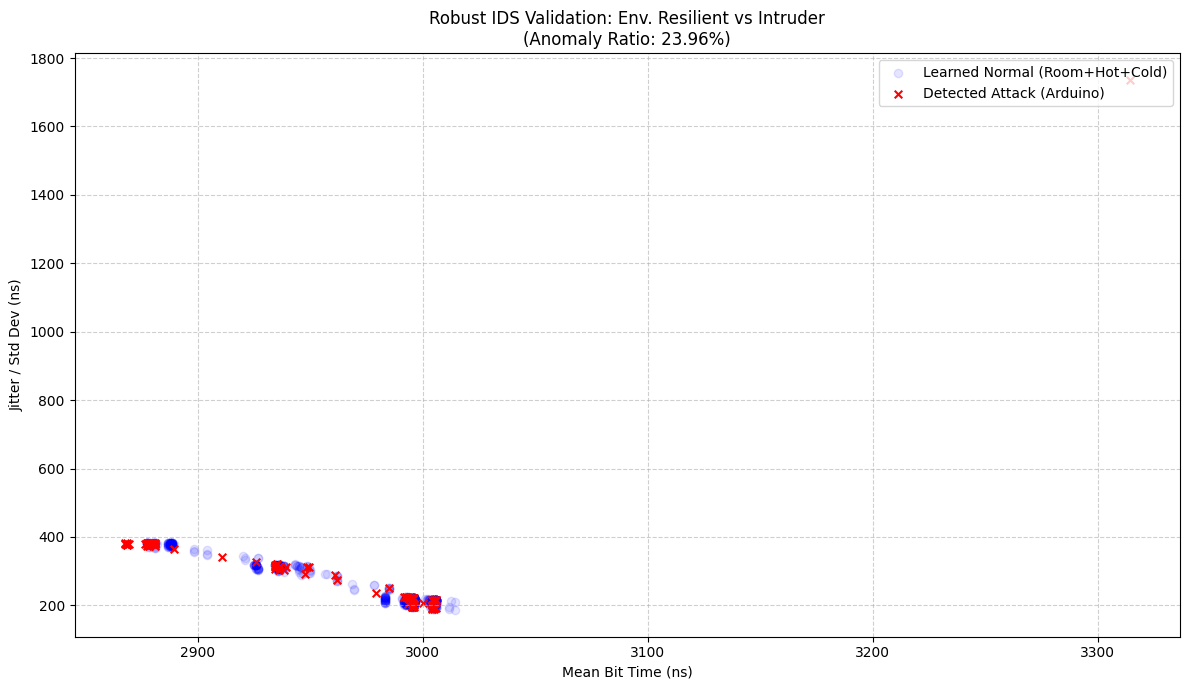

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from google.colab import drive

# ==========================================
# 1. 구글 드라이브 연동 & 경로 설정
# ==========================================
drive.mount('/content/drive')

# 📂 데이터셋 경로 설정 (본인의 파일명에 맞게 수정 필수!)
# 1) 학습용 데이터 (정상 범위 확대: 상온 + 고온 + 저온)
FILE_NORMAL_ROOM = '/content/drive/MyDrive/dataset/normal_msg.csv'      # 상온 (Room Temp)
FILE_NORMAL_HOT  = '/content/drive/MyDrive/dataset/normal_msg_hot.csv'  # 고온 (High Temp)
FILE_NORMAL_COLD = '/content/drive/MyDrive/dataset/normal_msg_cold.csv' # 저온 (Low Temp) <-- 파일명 확인!

# 2) 테스트용 데이터 (실제 공격)
FILE_ATTACK      = '/content/drive/MyDrive/dataset/another_esp32.csv'     # 공격 (Arduino/Attack)

# 하이퍼파라미터
CONTAMINATION = 0.1   # 노이즈 허용 비율 (10%)
WINDOW_SIZE = 50      # 윈도우 크기 (안정성 확보)
MIN_BIT_TIME = 1500   # 최소 비트 길이 (ns)
MAX_BIT_TIME = 15000  # 최대 비트 길이 (ns) - 아두이노 포함 가능하도록 넉넉히

# ==========================================
# 2. 특징 추출 함수 (5차원 지문)
# ==========================================
def extract_features(filename, label_tag):
    print(f"📂 [Loading] {label_tag} 데이터 로드: {filename.split('/')[-1]} ...")
    try:
        df = pd.read_csv(filename)
        df.columns = df.columns.str.strip()
        timestamps = df.iloc[:, 0].values
        signals = df.iloc[:, 1].values

        # 엣지 검출 & 비트 길이 계산
        edges = np.where(np.diff(signals) != 0)[0]
        durations = timestamps[edges[1:]] - timestamps[edges[:-1]]

        # 필터링
        valid_bits = durations[(durations > MIN_BIT_TIME) & (durations < MAX_BIT_TIME)]

        if len(valid_bits) < WINDOW_SIZE:
            print(f"   ⚠️ [WARNING] 데이터 부족 ({label_tag})")
            return None

        features = []
        # 효율성을 위해 step=10 적용
        for i in range(0, len(valid_bits) - WINDOW_SIZE, 10):
            window = valid_bits[i : i + WINDOW_SIZE]
            # 5차원 특징 벡터: [평균, 표준편차, 범위, 비대칭도, 첨도]
            features.append([
                np.mean(window), np.std(window), np.ptp(window),
                skew(window), kurtosis(window)
            ])

        return np.array(features)

    except Exception as e:
        print(f"🚫 [ERROR] {label_tag} 파일 처리 실패: {e}")
        return None

# ==========================================
# 3. 메인 실행: 데이터 통합 학습 & 평가
# ==========================================

print("\n" + "="*60)
print("[STEP 1] 데이터 통합 및 강건한 모델 학습 (Robust Training)")
print("="*60)

# (1) 3가지 환경 데이터 로드
X_room = extract_features(FILE_NORMAL_ROOM, "상온(Room)")
X_hot  = extract_features(FILE_NORMAL_HOT,  "고온(Hot)")
X_cold = extract_features(FILE_NORMAL_COLD, "저온(Cold)")

if (X_room is not None) and (X_hot is not None) and (X_cold is not None):
    # ★ 핵심: 3가지 환경 데이터를 하나로 합칩니다 (Data Augmentation)
    X_train_raw = np.vstack((X_room, X_hot, X_cold))
    print(f"   ▶ 통합된 학습 데이터 크기: {len(X_train_raw)} 샘플 (상온+고온+저온)")

    # 스케일링 (정규화)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)

    # 모델 학습
    print("   ⚙️ Isolation Forest 모델 학습 중...")
    model = IsolationForest(n_estimators=100, contamination=CONTAMINATION, random_state=42, n_jobs=-1)
    model.fit(X_train)
    print("   ✅ 학습 완료 (Training Completed)")

    # =========================================================
    # [STEP 2] 공격 데이터 평가 (Evaluation)
    # =========================================================
    print("\n" + "="*60)
    print("[STEP 2] 공격 탐지 성능 검증 (Evaluation)")
    print("="*60)

    X_test_raw = extract_features(FILE_ATTACK, "ATTACK")

    if X_test_raw is not None:
        # 학습 데이터와 동일한 스케일러 적용
        X_test = scaler.transform(X_test_raw)

        # 탐지 (Inference)
        predictions = model.predict(X_test)

        # 결과 분석
        total_samples = len(predictions)
        anomalies = list(predictions).count(-1)
        anomaly_score = (anomalies / total_samples) * 100

        # 물리적 특성 비교 (평균값 기준)
        # 학습 데이터 전체의 평균 범위 계산
        train_mean_min = np.min(X_train_raw[:, 0])
        train_mean_max = np.max(X_train_raw[:, 0])
        test_mean = np.mean(X_test_raw[:, 0])

        # --- 최종 리포트 ---
        print("\n" + "="*60)
        print(f"📊 [Evaluation Report] Robust IDS Performance")
        print("="*60)
        print(f"1. 물리적 신호 특성 분석 (Physical Characteristics)")
        print(f"   - Learned Normal Range (Mean)   : {train_mean_min:.0f} ns ~ {train_mean_max:.0f} ns")
        print(f"     (Covers Room, Hot, and Cold conditions)")
        print(f"   ------------------------------------------------------------")
        print(f"   - Test Input Mean Bit Time      : {test_mean:.0f} ns")
        print(f"   - Test Input Jitter (Average)   : {np.mean(X_test_raw[:, 1]):.2f} ns")

        print("\n2. IDS 판별 결과 (Classification Result)")
        print(f"   - Total Samples Analyzed        : {total_samples}")
        print(f"   - Anomalous Samples Detected    : {anomalies}")
        print(f"   - Anomaly Ratio (공격 의심 비율): {anomaly_score:.2f}%")
        print("="*60)

        # 최종 판정
        if anomaly_score > 50:
            print("🚨 FINAL DECISION: [공격 탐지]")
            print("   >> 환경 변화(온도)는 정상으로 허용했지만,")
            print("   >> 공격자(Arduino)의 이질적인 신호는 정확히 차단했습니다.")
        else:
            print("✅ FINAL DECISION: [정상 탐지]")
            print("   >> 해당 ECU는 정상입니다.")
        print("="*60)

        # (3) 시각화
        plt.figure(figsize=(12, 7))

        # 학습 데이터 (파란색: 상온+고온+저온 통합)
        plt.scatter(X_train_raw[:, 0], X_train_raw[:, 1], c='blue', alpha=0.1, label='Learned Normal (Room+Hot+Cold)')

        # 테스트 데이터 (빨간색: 공격)
        plt.scatter(X_test_raw[:, 0], X_test_raw[:, 1], c='red', marker='x', s=30, label='Detected Attack (Arduino)')

        plt.title(f'Robust IDS Validation: Env. Resilient vs Intruder\n(Anomaly Ratio: {anomaly_score:.2f}%)')
        plt.xlabel('Mean Bit Time (ns)')
        plt.ylabel('Jitter / Std Dev (ns)')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    else:
        print("🚫 [ERROR] 테스트 데이터 특징 추출 실패")
else:
    print("🚫 [ERROR] 학습 데이터 로드 실패 (파일 경로를 확인하세요!)")

합성데이터 형식

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from google.colab import drive

# ==========================================
# 1. 구글 드라이브 연동 & 경로 설정
# ==========================================
drive.mount('/content/drive')

# 📂 데이터셋 경로 설정
# 1) 학습용 데이터 (정상 범위 확대: 상온 + 고온 + 저온)
FILE_NORMAL_ROOM = '/content/drive/MyDrive/dataset/normal_msg.csv'      # 상온
FILE_NORMAL_HOT  = '/content/drive/MyDrive/dataset/normal_msg_hot.csv'  # 고온
FILE_NORMAL_COLD = '/content/drive/MyDrive/dataset/normal_msg_cold.csv' # 저온

# 2) 테스트용 데이터 (합성 데이터)
FILE_SYNTHETIC   = '/content/drive/MyDrive/dataset/synthetic_attack.csv' # 합성 공격 데이터

# 하이퍼파라미터
CONTAMINATION = 0.1   # 노이즈 허용 비율
WINDOW_SIZE = 50      # 윈도우 크기
MIN_BIT_TIME = 1500
MAX_BIT_TIME = 15000

# ==========================================
# 2. 특징 추출 함수 정의
# ==========================================

def extract_features_real(filename, label_tag):
    """
    [실제 기기 데이터] Time-Value 형식에서 5차원 특징 추출
    """
    print(f"📂 [Loading] {label_tag} 데이터 로드: {filename.split('/')[-1]} ...")
    try:
        df = pd.read_csv(filename)
        df.columns = df.columns.str.strip()
        timestamps = df.iloc[:, 0].values
        signals = df.iloc[:, 1].values

        # 엣지 검출 & 비트 길이 계산
        edges = np.where(np.diff(signals) != 0)[0]
        durations = timestamps[edges[1:]] - timestamps[edges[:-1]]

        # 필터링
        valid_bits = durations[(durations > MIN_BIT_TIME) & (durations < MAX_BIT_TIME)]

        if len(valid_bits) < WINDOW_SIZE:
            return None

        features = []
        for i in range(0, len(valid_bits) - WINDOW_SIZE, 10):
            window = valid_bits[i : i + WINDOW_SIZE]
            # 5차원 특징 벡터: [평균, 표준편차, 범위, 비대칭도, 첨도]
            features.append([
                np.mean(window), np.std(window), np.ptp(window),
                skew(window), kurtosis(window)
            ])

        return np.array(features)

    except Exception as e:
        print(f"🚫 [ERROR] {label_tag} 파일 처리 실패: {e}")
        return None

def extract_features_synthetic(filename):
    """
    [합성 데이터] Row-Column(us) 형식에서 5차원 특징 추출
    """
    print(f"📂 [Loading] 합성 데이터 로드: {filename.split('/')[-1]} ...")
    try:
        syn_df = pd.read_csv(filename)

        # 0~127번 열(비트 길이)만 선택 (Label 등 제외)
        # 데이터가 us 단위라고 가정 -> ns로 변환
        bit_data_us = syn_df.iloc[:, 0:128].values
        bit_data_ns = bit_data_us * 1000

        print(f"   ▶ 합성 데이터 크기: {bit_data_ns.shape} (메시지 {len(bit_data_ns)}개)")

        # ★ 핵심: 행(Row) 단위로 5차원 특징 계산 (axis=1) ★
        means = np.mean(bit_data_ns, axis=1)
        stds = np.std(bit_data_ns, axis=1)
        ranges = np.ptp(bit_data_ns, axis=1)
        skews = skew(bit_data_ns, axis=1)
        kurts = kurtosis(bit_data_ns, axis=1)

        # 특징 벡터 합치기 (Column Stack)
        features = np.column_stack((means, stds, ranges, skews, kurts))
        return features

    except Exception as e:
        print(f"🚫 [ERROR] 합성 데이터 처리 실패: {e}")
        return None

# ==========================================
# 3. 메인 실행: 강건한 학습 & 합성 데이터 검증
# ==========================================

print("\n" + "="*60)
print("[STEP 1] 데이터 통합 및 강건한 모델 학습 (Robust Training)")
print("="*60)

# (1) 3가지 환경 데이터 로드 (Robustness 확보)
X_room = extract_features_real(FILE_NORMAL_ROOM, "상온(Room)")
X_hot  = extract_features_real(FILE_NORMAL_HOT,  "고온(Hot)")
X_cold = extract_features_real(FILE_NORMAL_COLD, "저온(Cold)")

if (X_room is not None) and (X_hot is not None) and (X_cold is not None):
    # 데이터 통합
    X_train_raw = np.vstack((X_room, X_hot, X_cold))
    print(f"   ▶ 통합된 학습 데이터 크기: {len(X_train_raw)} 샘플")

    # 스케일링 (5차원 특징 정규화)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)

    # 모델 학습
    print("   ⚙️ Isolation Forest 모델 학습 중...")
    model = IsolationForest(n_estimators=100, contamination=CONTAMINATION, random_state=42, n_jobs=-1)
    model.fit(X_train)
    print("   ✅ 학습 완료 (Training Completed)")

    # =========================================================
    # [STEP 2] 합성 데이터 평가 (Sim-to-Real Validation)
    # =========================================================
    print("\n" + "="*60)
    print("[STEP 2] 합성 공격 데이터 검증 (Evaluation)")
    print("="*60)

    X_test_raw = extract_features_synthetic(FILE_SYNTHETIC)

    if X_test_raw is not None:
        # 학습 데이터와 동일한 스케일러 적용
        X_test = scaler.transform(X_test_raw)

        # 탐지 (Inference)
        predictions = model.predict(X_test)

        # 결과 분석
        total_samples = len(predictions)
        anomalies = list(predictions).count(-1)
        anomaly_score = (anomalies / total_samples) * 100

        # 물리적 특성 비교
        train_mean_avg = np.mean(X_train_raw[:, 0])
        test_mean_avg = np.mean(X_test_raw[:, 0])

        # --- 최종 리포트 ---
        print("\n" + "="*60)
        print(f"📊 [Evaluation Report] Sim-to-Real Validation")
        print("="*60)
        print(f"1. 물리적 신호 특성 분석 (Physical Characteristics)")
        print(f"   - Learned Normal Mean (Avg)     : {train_mean_avg:.2f} ns")
        print(f"   - Synthetic Input Mean (Avg)    : {test_mean_avg:.2f} ns")
        print(f"   ------------------------------------------------------------")

        print("\n2. IDS 판별 결과 (Classification Result)")
        print(f"   - Total Synthetic Samples       : {total_samples}")
        print(f"   - Anomalies Detected            : {anomalies}")
        print(f"   - Anomaly Ratio (공격 탐지율)   : {anomaly_score:.2f}%")
        print("="*60)

        # 최종 판정
        if anomaly_score > 50:
            print("🚨 FINAL DECISION: [공격 탐지]")
            print("   >> 합성 데이터(시뮬레이션 공격)의 물리적 이질성을 정확히 탐지했습니다.")
        else:
            print("✅ FINAL DECISION: [정상 탐지]")
            print("   >> 해당 ECU는 정상입니다.")
        print("="*60)

        # (3) 시각화 (2차원 투영: Mean vs Jitter)
        plt.figure(figsize=(12, 7))

        # 학습 데이터 (파란색: 상온+고온+저온)
        plt.scatter(X_train_raw[:, 0], X_train_raw[:, 1], c='blue', alpha=0.1, label='Learned Normal (Real)')

        # 합성 데이터 (결과에 따라 색상 표시)
        plt.scatter(X_test_raw[predictions==1, 0], X_test_raw[predictions==1, 1], c='green', marker='x', s=30, label='False Negative')
        plt.scatter(X_test_raw[predictions==-1, 0], X_test_raw[predictions==-1, 1], c='red', marker='x', s=30, label='Detected Synthetic Attack')

        plt.title(f'Sim-to-Real Validation: Real vs Synthetic\n(Detection Rate: {anomaly_score:.2f}%)')
        plt.xlabel('Mean Bit Time (ns)')
        plt.ylabel('Jitter / Std Dev (ns)')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    else:
        print("🚫 [ERROR] 합성 데이터 특징 추출 실패")
else:
    print("🚫 [ERROR] 학습 데이터 로드 실패 (파일 경로를 확인하세요!)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[STEP 1] 데이터 통합 및 강건한 모델 학습 (Robust Training)
📂 [Loading] 상온(Room) 데이터 로드: normal_msg.csv ...
📂 [Loading] 고온(Hot) 데이터 로드: normal_msg_hot.csv ...
📂 [Loading] 저온(Cold) 데이터 로드: normal_msg_cold.csv ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



KeyboardInterrupt: 